# 🏡 Modelado Predictivo del Valor de la Vivienda en California

**Ciencia de Datos — Ejercicio de Regresión**

El objetivo es predecir el valor medio de las casas en los distritos de California
(`MedHouseVal`) y comparar 4 modelos de regresión para ver cuál maneja mejor las
relaciones no lineales del dataset:

1. Regresión Lineal Múltiple (baseline)
2. Regresión Polinómica (grado 2)
3. Árbol de Regresión completo (sin límite de profundidad)
4. Árbol de Regresión podado (`max_depth=5`)

Cada modelo se evalúa en el conjunto de testeo con **MAE**, **RMSE** y **R²**.

## Bloque 1 — Importar librerías y cargar los datos

Cargamos las librerías y el dataset `california_housing`, que ya viene incluido
en scikit-learn. Tiene unos 20.640 distritos de California y, para cada uno, 8
variables (ingreso medio de la zona, antigüedad de las casas, habitaciones,
latitud, longitud, etc.). Lo que queremos predecir es `MedHouseVal`: el valor
medio de la vivienda, en unidades de 100.000 dólares.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cargar el dataset
california = fetch_california_housing(as_frame=True)
df = california.frame    # dataset completo (variables + target) en un DataFrame
X = california.data      # las 8 variables predictoras
y = california.target    # MedHouseVal: lo que queremos predecir

print(df.shape)
print(df.head())

(20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


**Qué vemos:** el dataset tiene 20.640 filas (distritos) y 9 columnas: las 8
variables predictoras más la columna `MedHouseVal` que es el target. Todas las
variables son numéricas y continuas, así que no hace falta encodear nada.

## Bloque 2 — Análisis exploratorio (EDA)

Antes de modelar conviene entender los datos. Calculamos la **matriz de
correlación**: nos dice qué tan relacionada está cada variable con las demás (y
sobre todo con el precio). Un valor cercano a 1 o -1 = relación fuerte; cercano a
0 = casi sin relación lineal.

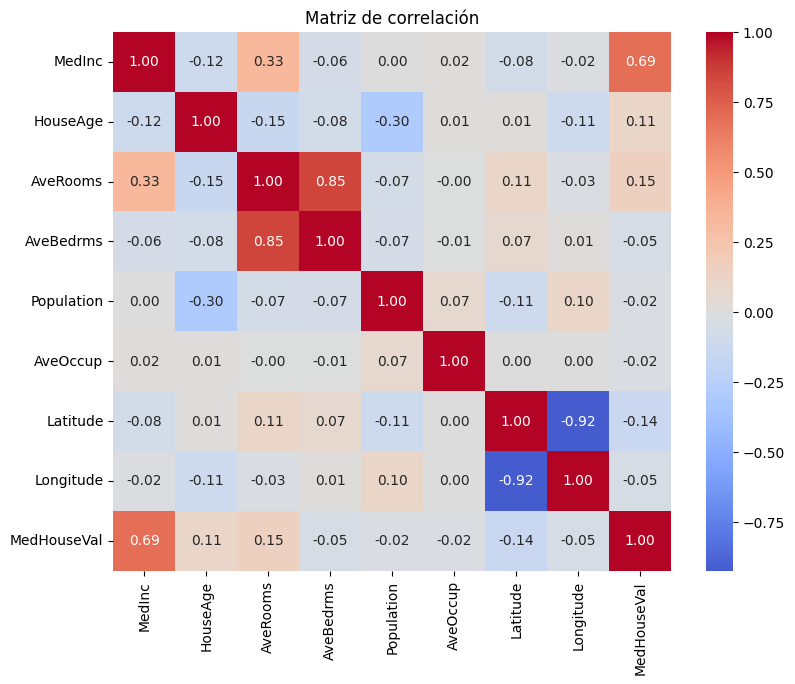

Correlación de cada variable con MedHouseVal:
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


In [2]:
# Matriz de correlación de todas las variables
corr = df.corr()

# Mapa de calor (heatmap)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Matriz de correlación")
plt.show()

# ¿Qué variable se correlaciona más con el precio?
print("Correlación de cada variable con MedHouseVal:")
print(corr['MedHouseVal'].sort_values(ascending=False))

**Qué dice esto:** la variable que más se relaciona con el precio es
`MedInc` (el ingreso medio de la zona), con una correlación de **0.69** — bastante
fuerte. Tiene sentido: en zonas donde la gente gana más, las casas valen más.

El resto de las variables tienen correlaciones bajísimas (todas por debajo de
0.16). Eso ya nos adelanta algo: el precio **no depende de forma lineal simple**
de casi ninguna variable suelta. Por eso después vamos a probar modelos que
captan relaciones más complejas.

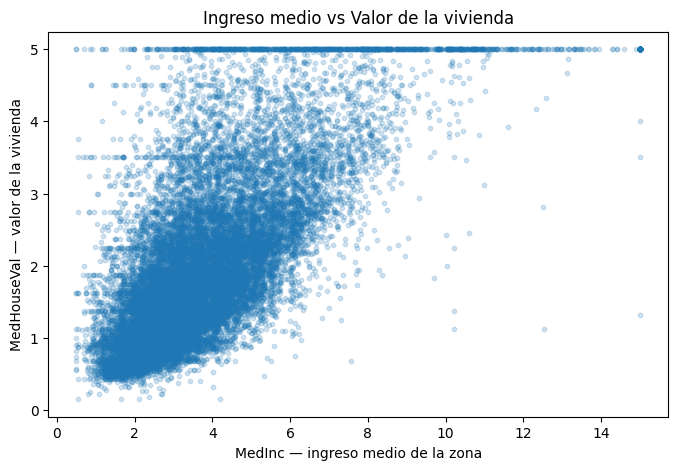

In [3]:
# Scatter plot: la variable más correlacionada (MedInc) vs el precio
plt.figure(figsize=(8, 5))
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.2, s=10)
plt.xlabel("MedInc — ingreso medio de la zona")
plt.ylabel("MedHouseVal — valor de la vivienda")
plt.title("Ingreso medio vs Valor de la vivienda")
plt.show()

**Qué vemos en el gráfico:** hay una tendencia clara — a mayor ingreso,
mayor valor de la vivienda. Pero la nube de puntos es bien ancha: el ingreso
explica *parte* del precio, no todo.

Fijate también en la **línea de puntos arriba de todo, en 5.0**: el dataset tiene
el precio "tope" recortado en 500.000 dólares. Esos son los valores atípicos que
después le van a costar a los modelos.

## Bloque 3 — Dividir los datos y estandarizar

Separamos los datos en **train (80%)** para entrenar y **test (20%)** para
evaluar, con `random_state=42` para que sea reproducible.

Después **estandarizamos** con `StandardScaler`: deja todas las variables en la
misma escala (promedio 0, desvío 1). Esto es importante porque las variables
vienen en escalas muy distintas (ingreso, población, latitud...). Sin escalar,
la regresión lineal y sobre todo la polinómica le darían más peso a las variables
con números más grandes solo por su tamaño, no por su importancia real. Los
árboles no lo necesitan, pero usamos los mismos datos para todos.

In [4]:
# Split 80/20 con semilla fija
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Estandarizar las variables predictoras
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} distritos")
print(f"Test:  {X_test.shape[0]} distritos")

Train: 16512 distritos
Test:  4128 distritos


## Bloque 4 — Modelo 1: Regresión Lineal Múltiple

Empezamos con el modelo más simple, el **baseline**. La regresión lineal busca la
mejor combinación lineal de las 8 variables para predecir el precio (una especie
de "promedio ponderado" inteligente). Es nuestro punto de comparación: los otros
3 modelos tienen que superarlo.

In [5]:
# Modelo 1: Regresión Lineal Múltiple
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"MAE:  {mae_lr:.3f}")
print(f"RMSE: {rmse_lr:.3f}")
print(f"R²:   {r2_lr:.3f}")

MAE:  0.533
RMSE: 0.746
R²:   0.576


/Users/germanmieth/Desktop/titanic-random-forest/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/germanmieth/Desktop/titanic-random-forest/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/germanmieth/Desktop/titanic-random-forest/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


**Qué dan los resultados:**

- **R² = 0.576** → el modelo explica el 58% de la variación del precio. No está
  mal para un modelo tan simple, pero queda casi la mitad sin explicar.
- **RMSE = 0.746** → el error típico es de unos 74.600 dólares (recordá que el
  precio está en unidades de 100.000).
- **MAE = 0.533** → en promedio le erra unos 53.300 dólares.

Es un baseline razonable. La limitación: la regresión lineal asume que todo es
una línea recta, y ya vimos que los datos no son tan simples.

## Bloque 5 — Modelo 2: Regresión Polinómica (grado 2)

Las relaciones reales (sobre todo las geográficas, latitud/longitud) rara vez son
líneas rectas. Con `PolynomialFeatures(degree=2)` ampliamos las variables:
agregamos los cuadrados de cada una y las multiplicaciones entre pares. Eso le
permite al modelo lineal captar curvas e interacciones, sin dejar de ser una
regresión lineal por dentro.

In [6]:
# Modelo 2: Regresión Polinómica de grado 2
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print(f"Pasamos de {X_train_scaled.shape[1]} variables a {X_train_poly.shape[1]}")

# Entrenamos una regresión lineal sobre las variables ampliadas
poly_lr = LinearRegression()
poly_lr.fit(X_train_poly, y_train)
y_pred_poly = poly_lr.predict(X_test_poly)

mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print(f"MAE:  {mae_poly:.3f}")
print(f"RMSE: {rmse_poly:.3f}")
print(f"R²:   {r2_poly:.3f}")

Pasamos de 8 variables a 45
MAE:  0.467
RMSE: 0.681
R²:   0.646


/Users/germanmieth/Desktop/titanic-random-forest/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/germanmieth/Desktop/titanic-random-forest/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/germanmieth/Desktop/titanic-random-forest/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


**Qué dan los resultados:**

- Las 8 variables se convirtieron en **45** (cuadrados + combinaciones).
- **R² = 0.646** → subió del 58% al 65%. Mejoró bastante.
- **RMSE = 0.681** y **MAE = 0.467** → los dos errores bajaron respecto al modelo
  lineal simple.

Conclusión del bloque: darle al modelo la posibilidad de captar curvas e
interacciones **mejoró la predicción**. Las relaciones del dataset efectivamente
no eran lineales puras.

## Bloque 6 — Modelos 3 y 4: Árbol de Regresión (completo y podado)

Ahora un enfoque distinto: un **árbol de regresión**, que parte los datos en
grupos con reglas tipo "si el ingreso es mayor a X...".

Entrenamos dos versiones:
- **Árbol completo** (`max_depth=None`): se lo deja crecer sin límite.
- **Árbol podado** (`max_depth=5`): se le limita la profundidad a 5 niveles.

Medimos el R² en **train** además de en test, para ver el sobreajuste.

In [7]:
# Modelo 3: Árbol de Regresión completo (sin límite de profundidad)
tree_overfit = DecisionTreeRegressor(max_depth=None, random_state=42)
tree_overfit.fit(X_train_scaled, y_train)
y_pred_overfit = tree_overfit.predict(X_test_scaled)

# Modelo 4: Árbol de Regresión podado (profundidad máxima 5)
tree_pruned = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_pruned.fit(X_train_scaled, y_train)
y_pred_pruned = tree_pruned.predict(X_test_scaled)

# R² en train vs test para ver el sobreajuste
print("Árbol completo -> R² train:",
      round(r2_score(y_train, tree_overfit.predict(X_train_scaled)), 3),
      "| profundidad:", tree_overfit.get_depth())
print("Árbol podado   -> R² train:",
      round(r2_score(y_train, tree_pruned.predict(X_train_scaled)), 3),
      "| profundidad:", tree_pruned.get_depth())

Árbol completo -> R² train: 1.0 | profundidad: 34
Árbol podado   -> R² train: 0.638 | profundidad: 5


**Qué dan los resultados:**

- El **árbol completo** llegó a una profundidad de **34 niveles** y un **R² en
  train de 1.000**: predijo *perfecto* los datos de entrenamiento. Eso no es
  bueno — es la señal clásica de **sobreajuste (overfitting)**: se memorizó los
  datos en vez de aprender reglas generales.
- El **árbol podado** tiene **R² en train de 0.638**, mucho más bajo. No memorizó.

En el próximo bloque vamos a ver el R² de **test** de los dos, que es lo que de
verdad importa.

## Bloque 7 — Evaluación de los 4 modelos

Juntamos las 3 métricas de los 4 modelos en una tabla, calculadas sobre el
conjunto de **testeo** (datos que ningún modelo vio al entrenar):

- **MAE** → error promedio, en valor absoluto. Cuanto más bajo, mejor.
- **RMSE** → parecido, pero castiga más los errores grandes (los valores
  atípicos). Cuanto más bajo, mejor.
- **R²** → qué porcentaje de la variación del precio explica el modelo. Cuanto
  más cerca de 1, mejor.

In [8]:
# Evaluación de los 4 modelos en el conjunto de testeo
def metricas(y_pred):
    return [
        mean_absolute_error(y_test, y_pred),
        np.sqrt(mean_squared_error(y_test, y_pred)),
        r2_score(y_test, y_pred),
    ]

resultados = pd.DataFrame({
    'Lineal Múltiple':  metricas(y_pred_lr),
    'Polinómica (gº2)': metricas(y_pred_poly),
    'Árbol completo':   metricas(y_pred_overfit),
    'Árbol podado':     metricas(y_pred_pruned),
}, index=['MAE', 'RMSE', 'R²'])

print(resultados.round(3))

      Lineal Múltiple  Polinómica (gº2)  Árbol completo  Árbol podado
MAE             0.533             0.467           0.455         0.522
RMSE            0.746             0.681           0.706         0.724
R²              0.576             0.646           0.620         0.600


**Qué dice la tabla** (todo medido en test):

- **Lineal Múltiple** → R² 0.576, RMSE 0.746. El baseline.
- **Polinómica** → R² 0.646, RMSE 0.681. **El mejor de los cuatro**: el R² más
  alto y el RMSE más bajo.
- **Árbol completo** → R² 0.620 en test. Ojo el contraste: en train tenía 1.000 y
  en test bajó a 0.620. Esa caída enorme es el overfitting que anticipamos.
- **Árbol podado** → R² 0.600 en test. En train tenía 0.638, así que train y test
  dan casi igual: este modelo **generaliza de forma honesta**.

Detalle interesante: el árbol completo tiene el MAE más bajo (le pega bien al
caso típico), pero su RMSE es peor que el de la polinómica — o sea, comete
algunos errores grandes en los valores atípicos.

## Bloque 8 — Conclusión

El ejercicio pedía comparar 4 modelos de regresión y ver cuál maneja mejor el
dataset. La respuesta corta: el mejor fue la **Regresión Polinómica**.

La regresión lineal simple sirve como baseline pero se queda corta (R² 0.576):
asume que todo es una línea recta y los datos no son así. Cuando con
`PolynomialFeatures` le dimos lugar a captar curvas e interacciones, el R² subió
a 0.646 y los errores bajaron. Las relaciones del dataset no eran lineales, y el
modelo polinómico lo aprovechó.

El contraste entre los dos árboles es la otra enseñanza del ejercicio. El árbol
completo, sin límite de profundidad, predijo perfecto el entrenamiento (R² 1.000)
pero en test cayó a 0.620: memorizó en lugar de generalizar, eso es overfitting.
El árbol podado a profundidad 5 dio casi lo mismo en train que en test (0.638 vs
0.600): sacrificó un poquito de precisión a cambio de ser confiable y no
sobreajustar. Limitar la complejidad fue lo que controló el overfitting.

En resumen: para este problema la polinómica de grado 2 fue la que mejor
equilibró captar las no linealidades sin sobreajustar.